# CS503 - Project Leukemia Type Classification from Gene Expression


### Dataset Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/CS503_Project/Leukemia_GSE28497.csv', index_col = 0)
# df = pd.read_csv('/content/drive/MyDrive/CS503_Project/Leukemia_GSE9476.csv', index_col = 0)

## Dataset Description

In [ ]:
df.head()

,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,...,AFFX-r2-Hs28SrRNA-5_at,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
samples,,,,,,,,,,,,,,,,,,,,,
GSM705467.CEL.gz,B-CELL_ALL,7.409521,5.009216,4.173607,7.315369,3.185411,7.620644,3.731541,3.471587,4.167374,...,2.968822,3.223820,11.968681,12.100004,3.457507,2.967138,2.790814,2.563377,2.860505,2.608381
GSM705468.CEL.gz,B-CELL_ALL,7.177109,5.415108,4.426778,7.550818,3.134181,7.685723,3.907953,3.650995,3.860015,...,2.982888,3.690411,12.318004,12.486741,3.396412,3.109629,2.856499,2.603355,2.908509,2.634063
GSM705469.CEL.gz,B-CELL_ALL,6.564918,5.248020,4.252414,7.175169,3.017718,7.956261,3.354557,3.302989,3.335324,...,2.897425,3.611584,11.748222,11.807578,3.265585,3.057079,2.724642,2.440532,2.626871,2.673293
GSM705470.CEL.gz,B-CELL_ALL,6.872028,5.155963,4.388849,7.365933,3.031735,7.830002,3.508926,3.412491,3.439769,...,3.024722,3.713087,12.208588,12.148604,3.175092,2.896168,2.798296,2.522343,2.762835,2.624163
GSM705471.CEL.gz,B-CELL_ALL,7.402105,5.509826,4.284291,7.214947,2.925269,7.789838,3.610425,3.362593,3.412095,...,3.259802,4.096010,11.641305,11.713311,3.507025,3.119397,2.761294,2.546541,2.748511,2.738165


In [ ]:
df.shape

(281, 22284)

In [ ]:
df.describe()

,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Hs28SrRNA-5_at,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
count,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000,...,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000,281.000000
mean,6.536689,5.220441,4.386666,7.180101,3.035960,7.223307,3.565429,3.341773,3.704876,2.884854,...,3.115059,3.729149,12.072149,12.088670,3.382296,2.997874,2.766289,2.559077,2.795401,2.716808
std,0.471496,0.259670,0.271166,0.240994,0.104344,0.510499,0.159564,0.128751,0.658484,0.133552,...,0.205080,0.361915,0.354977,0.407046,0.138426,0.124333,0.089199,0.071539,0.099519,0.091987
min,5.326125,4.566413,3.932979,6.639985,2.800599,5.693636,3.082068,3.002259,2.767301,2.537903,...,2.607524,2.979023,10.945028,10.741512,3.086645,2.711472,2.540938,2.390125,2.519552,2.451768
25%,6.231565,5.048399,4.245621,7.018885,2.957267,6.857912,3.457256,3.256380,3.335324,2.801828,...,2.982888,3.495307,11.857283,11.834308,3.288405,2.909708,2.704972,2.509707,2.729274,2.664536
50%,6.521622,5.175188,4.326353,7.154824,3.036026,7.279566,3.551111,3.335495,3.517907,2.881841,...,3.095593,3.679705,12.078667,12.109107,3.375961,2.990293,2.757912,2.545637,2.794410,2.708510
75%,6.857385,5.404485,4.461008,7.343525,3.091002,7.601813,3.664568,3.410941,3.803802,2.950387,...,3.227073,3.908739,12.287972,12.353300,3.465035,3.072707,2.815273,2.601998,2.860917,2.767122
max,8.207525,6.096988,6.678337,7.898316,3.376320,8.521494,4.147451,3.764350,7.617986,3.991963,...,4.104472,5.958647,12.982387,13.080044,4.123147,3.519577,3.044678,2.810610,3.084154,3.172956


In [ ]:
y = df['type']
X = df.iloc[:, 1:]

In [ ]:
X.head()

,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Hs28SrRNA-5_at,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
samples,,,,,,,,,,,,,,,,,,,,,
GSM705467.CEL.gz,7.409521,5.009216,4.173607,7.315369,3.185411,7.620644,3.731541,3.471587,4.167374,2.873572,...,2.968822,3.223820,11.968681,12.100004,3.457507,2.967138,2.790814,2.563377,2.860505,2.608381
GSM705468.CEL.gz,7.177109,5.415108,4.426778,7.550818,3.134181,7.685723,3.907953,3.650995,3.860015,2.900938,...,2.982888,3.690411,12.318004,12.486741,3.396412,3.109629,2.856499,2.603355,2.908509,2.634063
GSM705469.CEL.gz,6.564918,5.248020,4.252414,7.175169,3.017718,7.956261,3.354557,3.302989,3.335324,2.811931,...,2.897425,3.611584,11.748222,11.807578,3.265585,3.057079,2.724642,2.440532,2.626871,2.673293
GSM705470.CEL.gz,6.872028,5.155963,4.388849,7.365933,3.031735,7.830002,3.508926,3.412491,3.439769,2.910715,...,3.024722,3.713087,12.208588,12.148604,3.175092,2.896168,2.798296,2.522343,2.762835,2.624163
GSM705471.CEL.gz,7.402105,5.509826,4.284291,7.214947,2.925269,7.789838,3.610425,3.362593,3.412095,2.876959,...,3.259802,4.096010,11.641305,11.713311,3.507025,3.119397,2.761294,2.546541,2.748511,2.738165


In [ ]:
y.value_counts()

,count
type,
B-CELL_ALL,74
B-CELL_ALL_ETV6-RUNX1,53
B-CELL_ALL_HYPERDIP,51
B-CELL_ALL_T-ALL,46
B-CELL_ALL_TCF3-PBX1,22
B-CELL_ALL_HYPO,18
B-CELL_ALL_MLL,17


## Data Cleaning and Preprocessing

### Cleaning Data

In [ ]:
# check for any missing values in data
sum(X.isnull().sum())

0

In [ ]:
df.duplicated()

,0
samples,
GSM705467.CEL.gz,False
GSM705468.CEL.gz,False
GSM705469.CEL.gz,False
GSM705470.CEL.gz,False
GSM705471.CEL.gz,False
...,...
GSM706002.CEL.gz,False
GSM706003.CEL.gz,False
GSM706004.CEL.gz,False


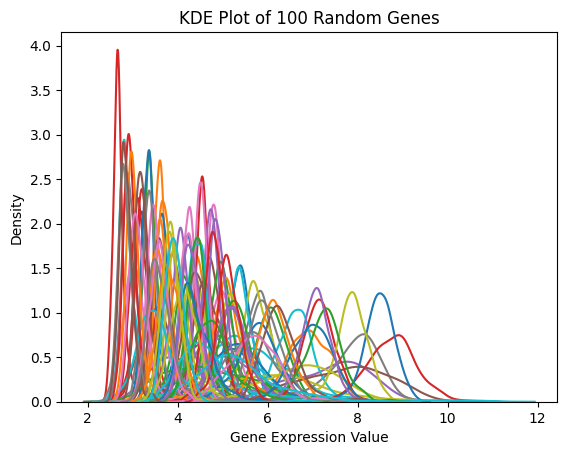

In [ ]:
import random

# Assuming 'X' is your DataFrame of gene expression data
random_genes = random.sample(list(X.columns), 100)
random_genes_df = X[random_genes]

for gene in random_genes:
    sns.kdeplot(random_genes_df[gene], label=gene)

plt.xlabel('Gene Expression Value')
plt.ylabel('Density')
plt.title('KDE Plot of 100 Random Genes')
plt.show()

In [ ]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,stratify=y,random_state=42)

### Synthetic Minority Oversampling Technique

SMOTE is used to synthesize data for better clustering and multi-class classification

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [ ]:
# observe sizes of new data
print(X_train.shape)
print(y_train.shape)

(385, 22283)
(385,)


## Model Selection

### Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the classifier
dt_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_classifier.predict(X_test)

Decision Tree Accuracy: 0.7464788732394366
                       precision    recall  f1-score   support

           B-CELL_ALL       0.69      0.58      0.63        19
B-CELL_ALL_ETV6-RUNX1       0.92      0.85      0.88        13
  B-CELL_ALL_HYPERDIP       0.63      0.92      0.75        13
      B-CELL_ALL_HYPO       0.20      0.25      0.22         4
       B-CELL_ALL_MLL       0.00      0.00      0.00         4
     B-CELL_ALL_T-ALL       1.00      1.00      1.00        12
 B-CELL_ALL_TCF3-PBX1       1.00      1.00      1.00         6

             accuracy                           0.75        71
            macro avg       0.63      0.66      0.64        71
         weighted avg       0.73      0.75      0.73        71



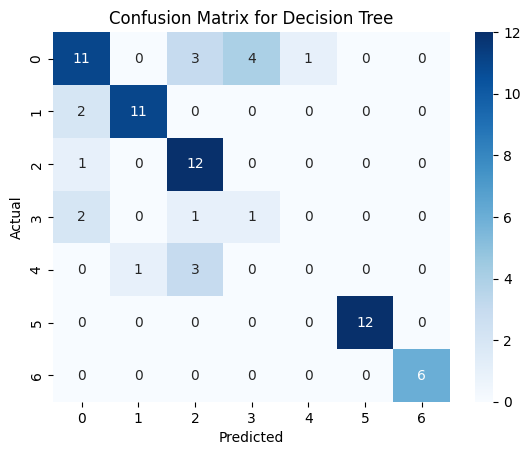

In [ ]:
# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt}")

print(classification_report(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Decision Tree')
plt.show()

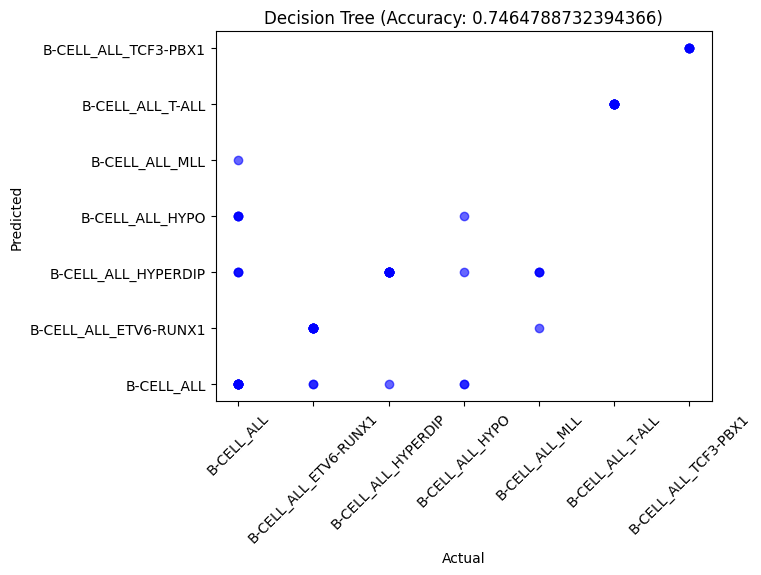

In [ ]:
labels = sorted(list(set(y_test.values) | set(y_pred_dt)))

# Map the labels to numerical indices for scatter plotting
y_test_mapped = [labels.index(label) for label in y_test.values]
y_pred_mapped = [labels.index(label) for label in y_pred_dt]

# Create the scatter plot
plt.scatter(y_test_mapped, y_pred_mapped, color='blue', alpha=0.6)
plt.title(f"Decision Tree (Accuracy: {accuracy_dt})")

# Set the ticks and labels on both axes
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45)
plt.yticks(ticks=range(len(labels)), labels=labels)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()


### Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Train the classifier
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

Random Forest Accuracy: 0.8591549295774648
                       precision    recall  f1-score   support

           B-CELL_ALL       0.75      0.79      0.77        19
B-CELL_ALL_ETV6-RUNX1       1.00      1.00      1.00        13
  B-CELL_ALL_HYPERDIP       0.75      0.92      0.83        13
      B-CELL_ALL_HYPO       0.50      0.25      0.33         4
       B-CELL_ALL_MLL       1.00      0.75      0.86         4
     B-CELL_ALL_T-ALL       1.00      1.00      1.00        12
 B-CELL_ALL_TCF3-PBX1       1.00      0.83      0.91         6

             accuracy                           0.86        71
            macro avg       0.86      0.79      0.81        71
         weighted avg       0.86      0.86      0.85        71



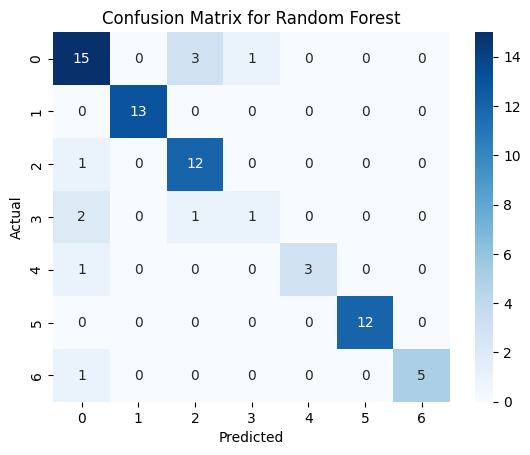

In [ ]:
# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf}")

print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest')
plt.show()

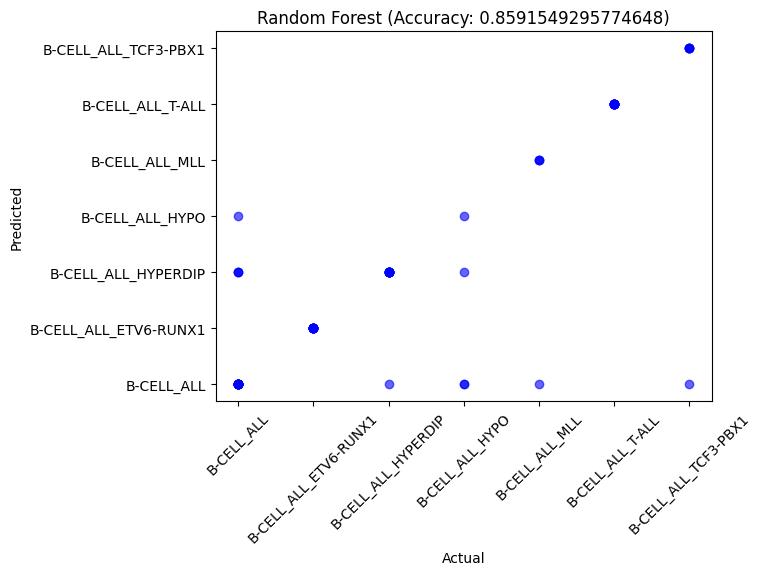

In [ ]:
labels = sorted(list(set(y_test.values) | set(y_pred_rf)))

# Map the labels to numerical indices for scatter plotting
y_test_mapped = [labels.index(label) for label in y_test.values]
y_pred_mapped = [labels.index(label) for label in y_pred_rf]

# Create the scatter plot
plt.scatter(y_test_mapped, y_pred_mapped, color='blue', alpha=0.6)
plt.title(f"Random Forest (Accuracy: {accuracy_rf})")

# Set the ticks and labels on both axes
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45)
plt.yticks(ticks=range(len(labels)), labels=labels)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

### Principal Component Analysis (PCA)

In [ ]:
# try PCA and take top 2 principal genes
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

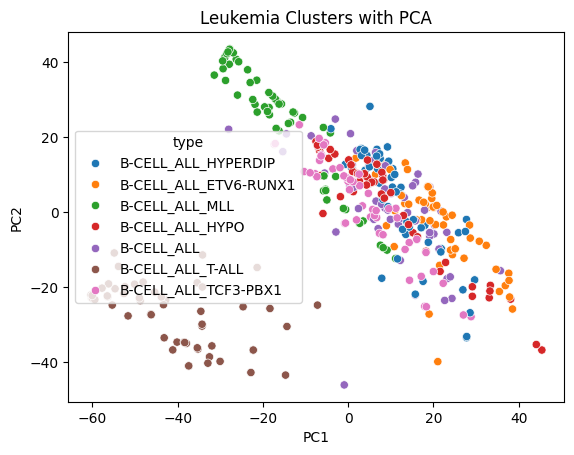

In [ ]:
# plot the types clusters with pca axes using seaborn
sns.scatterplot(x=X_train_pca[:,0], y=X_train_pca[:,1], hue=y_train)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Leukemia Clusters with PCA')
plt.show()

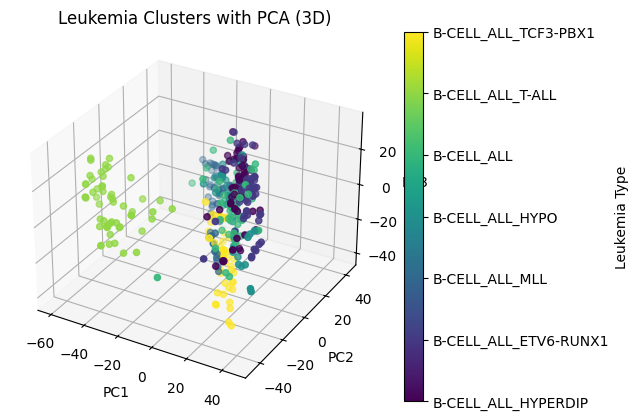

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Perform PCA with 3 components
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train)

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Convert categorical labels in 'y' to numerical values
# We use pandas' factorize method for this
y_numeric, unique_labels = pd.factorize(y_train)

# Scatter plot with color-coded points based on numerical 'y_numeric'
ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], c=y_numeric)

# Set labels for the axes
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

# Set title for the plot
ax.set_title('Leukemia Clusters with PCA (3D)')

# Create a colorbar and associate it with unique labels
cbar = plt.colorbar(ax.collections[0],  # Get the scatter plot collection
                    ticks=np.arange(len(unique_labels)), # Set tick positions
                    format='%1i')                      # Format tick labels as integers
cbar.set_ticklabels(unique_labels)  # Set tick labels to original categories
cbar.set_label('Leukemia Type')

# Display the plot
plt.show()

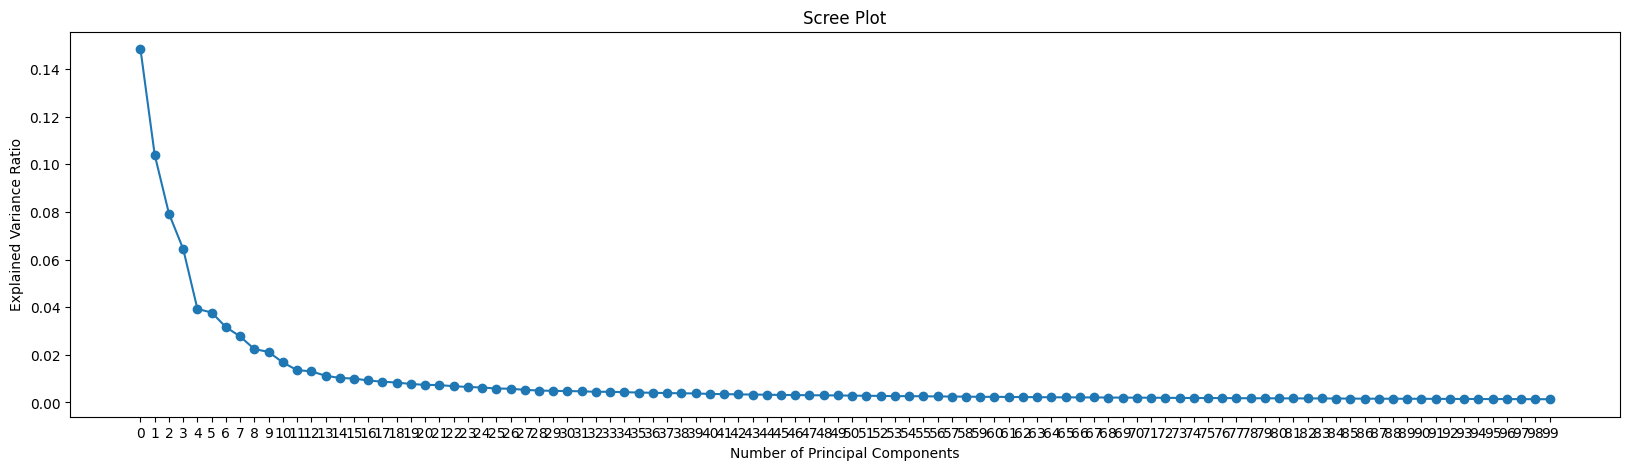

In [ ]:
# Create the scree plot
plot_pca = PCA()
plot_pca.fit(X_train)
explained_variance_ratio = plot_pca.explained_variance_ratio_
plt.figure(figsize=(20, 5))
plt.plot(range(0, 100), explained_variance_ratio[:100], marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.xticks(range(0, 100))
# expand x dimension of the plot in x axis so that it is clearly visible
plt.show()

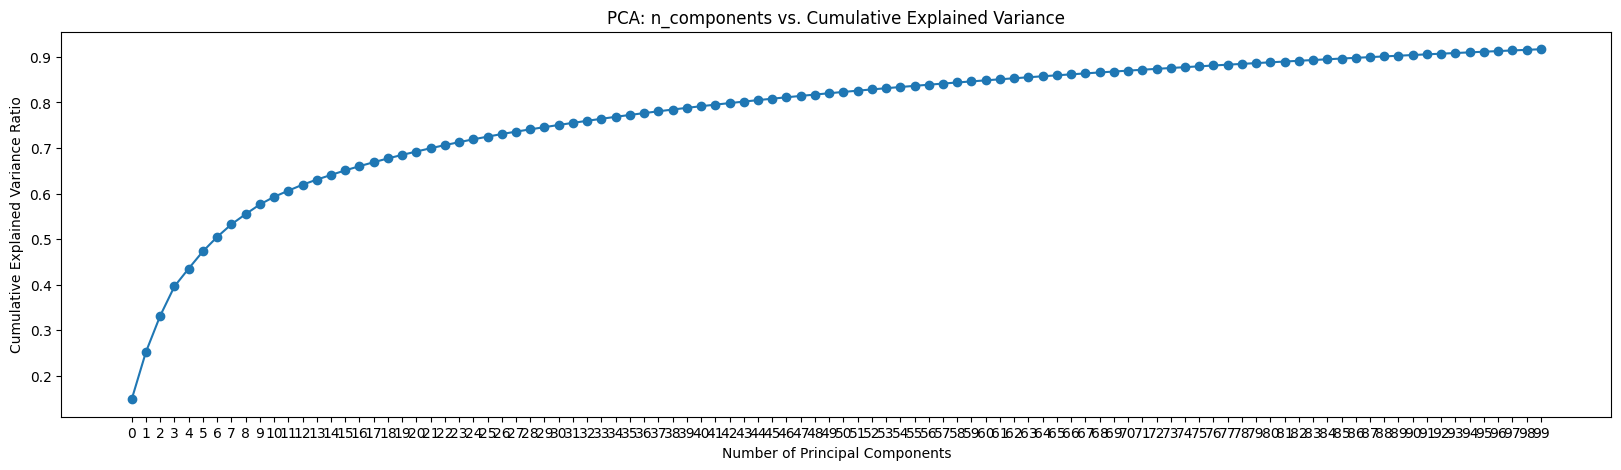

In [ ]:
# Calculate the cumulative explained variance ratio
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Plot n_components vs. cumulative explained variance
plt.figure(figsize=(20, 5))
plt.plot(range(0, 100), cumulative_variance_ratio[:100], marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA: n_components vs. Cumulative Explained Variance')
plt.xticks(range(0, 100))
plt.show()

### Linear Discriminant Analysis (LDA)

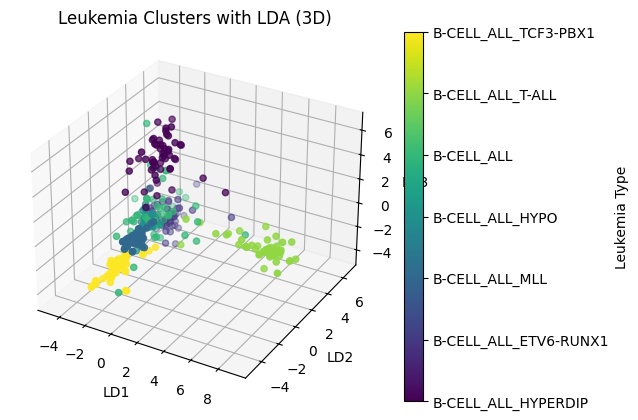

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Apply LDA with 3 components
lda = LDA(n_components=3)
X_train_lda = lda.fit_transform(X_train, y_train)

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Convert categorical labels in 'y' to numerical values
y_numeric, unique_labels = pd.factorize(y_train)

# Scatter plot with color-coded points
ax.scatter(X_train_lda[:, 0], X_train_lda[:, 1], X_train_lda[:, 2], c=y_numeric)

# Set labels and title
ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_zlabel('LD3')
ax.set_title('Leukemia Clusters with LDA (3D)')

# Create a colorbar
cbar = plt.colorbar(ax.collections[0], ticks=np.arange(len(unique_labels)), format='%1i')
cbar.set_ticklabels(unique_labels)
cbar.set_label('Leukemia Type')

# Display the plot
plt.show()

### t-distributed Stochastic Neighbor Embedding (t-SNE)

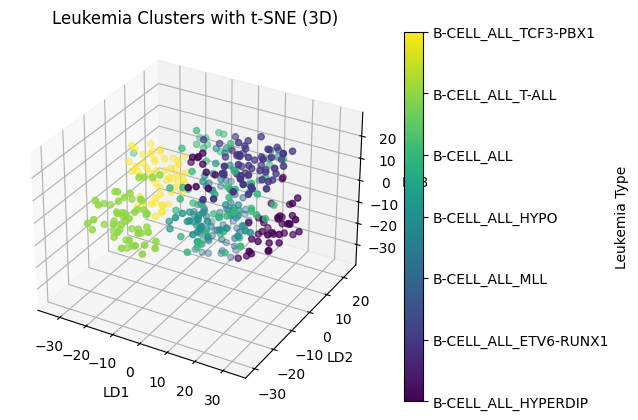

In [ ]:
# now apply t sne on data
from sklearn.manifold import TSNE
tsne = TSNE(n_components=3, random_state=42)
tsne_results = tsne.fit_transform(X_train)

# Create a 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Convert categorical labels in 'y' to numerical values
y_numeric, unique_labels = pd.factorize(y_train)

# Scatter plot with color-coded points
ax.scatter(tsne_results[:, 0], tsne_results[:, 1], tsne_results[:, 2], c=y_numeric)

# Set labels and title
ax.set_xlabel('LD1')
ax.set_ylabel('LD2')
ax.set_zlabel('LD3')
ax.set_title('Leukemia Clusters with t-SNE (3D)')

# Create a colorbar
cbar = plt.colorbar(ax.collections[0], ticks=np.arange(len(unique_labels)), format='%1i')
cbar.set_ticklabels(unique_labels)
cbar.set_label('Leukemia Type')

# Display the plot
plt.show()

### Model Comparision

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# pca accuracy
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
rf_pca = RandomForestClassifier(random_state=42)
rf_pca.fit(X_train_pca, y_train)
y_pred_pca = rf_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print(f"Accuracy with PCA: {accuracy_pca}")
# plot predicted vs actual

# LDA accuracy
lda = LDA(n_components=5)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)
rf_lda = RandomForestClassifier(random_state=42)
rf_lda.fit(X_train_lda, y_train)
y_pred_lda = rf_lda.predict(X_test_lda)
accuracy_lda = accuracy_score(y_test, y_pred_lda)
print(f"Accuracy with LDA: {accuracy_lda}")

# t-SNE accuracy
# Concatenate train and test data
X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))

tsne = TSNE(n_components=3, random_state=42, perplexity=min(30, len(X_train) - 1))
X_combined_tsne = tsne.fit_transform(X_combined)

# Split back into train and test sets
X_train_tsne = X_combined_tsne[:len(X_train)]
X_test_tsne = X_combined_tsne[len(X_train):]

# Train and predict
rf_tsne = RandomForestClassifier(random_state=42)
rf_tsne.fit(X_train_tsne, y_train)
y_pred_tsne = rf_tsne.predict(X_test_tsne)
# Calculate accuracy
accuracy_tsne = accuracy_score(y_test, y_pred_tsne)
print(f"Accuracy with t-SNE: {accuracy_tsne}")

Accuracy with PCA: 0.7746478873239436
Accuracy with LDA: 0.7887323943661971
Accuracy with t-SNE: 0.7605633802816901


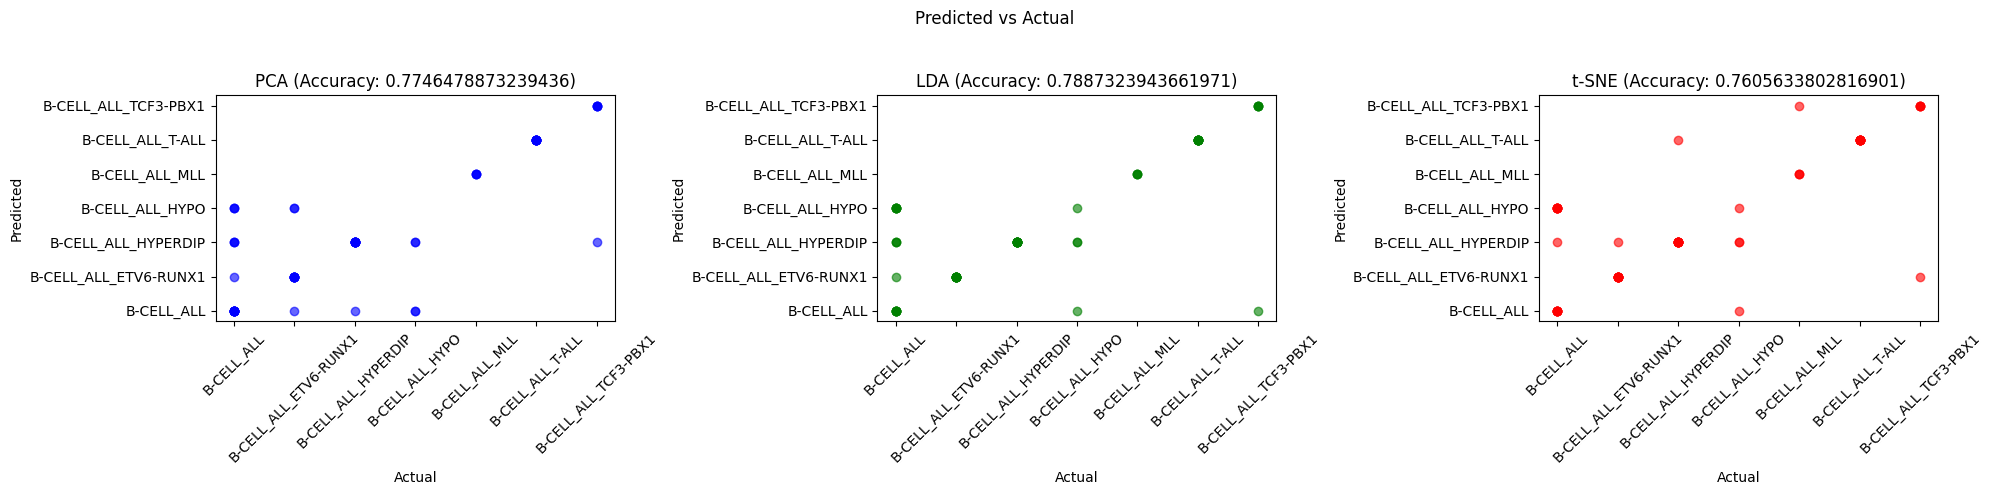

In [ ]:
labels = sorted(list(set(y_test) | set(y_pred_pca) | set(y_pred_lda) | set(y_pred_tsne)))

# Map the labels to numerical indices for scatter plotting
y_test_mapped = [labels.index(label) for label in y_test]
y_pred_pca_mapped = [labels.index(label) for label in y_pred_pca]
y_pred_lda_mapped = [labels.index(label) for label in y_pred_lda]
y_pred_tsne_mapped = [labels.index(label) for label in y_pred_tsne]

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Predicted vs Actual')

# PCA plot
axs[0].scatter(y_test_mapped, y_pred_pca_mapped, color="blue", alpha=0.6)
axs[0].set_title(f"PCA (Accuracy: {accuracy_pca})")
axs[0].set_xlabel("Actual")
axs[0].set_ylabel("Predicted")
axs[0].set_xticks(range(len(labels)))
axs[0].set_yticks(range(len(labels)))
axs[0].set_xticklabels(labels, rotation=45)
axs[0].set_yticklabels(labels)

# LDA plot
axs[1].scatter(y_test_mapped, y_pred_lda_mapped, color="green", alpha=0.6)
axs[1].set_title(f"LDA (Accuracy: {accuracy_lda})")
axs[1].set_xlabel("Actual")
axs[1].set_ylabel("Predicted")
axs[1].set_xticks(range(len(labels)))
axs[1].set_yticks(range(len(labels)))
axs[1].set_xticklabels(labels, rotation=45)
axs[1].set_yticklabels(labels)

# t-SNE plot
axs[2].scatter(y_test_mapped, y_pred_tsne_mapped, color="red", alpha=0.6)
axs[2].set_title(f"t-SNE (Accuracy: {accuracy_tsne})")
axs[2].set_xlabel("Actual")
axs[2].set_ylabel("Predicted")
axs[2].set_xticks(range(len(labels)))
axs[2].set_yticks(range(len(labels)))
axs[2].set_xticklabels(labels, rotation=45)
axs[2].set_yticklabels(labels)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Hybrid Modeling

In [ ]:
# hybrid modeling by ensembling
from sklearn.ensemble import VotingClassifier

# Already trained dt_classifier, rf_classifier, rf_pca, rf_lda, and rf_tsne

# Create a voting classifier
estimators = [('dt', dt_classifier), ('rf', rf_classifier), ('rf_pca', rf_pca), ('rf_lda', rf_lda), ('rf_tsne', rf_tsne)]
voting_classifier = VotingClassifier(estimators=estimators, voting='soft')

# Train the voting classifier
voting_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_voting = voting_classifier.predict(X_test)

Voting Classifier Accuracy: 0.8309859154929577
                       precision    recall  f1-score   support

           B-CELL_ALL       0.76      0.68      0.72        19
B-CELL_ALL_ETV6-RUNX1       1.00      0.92      0.96        13
  B-CELL_ALL_HYPERDIP       0.75      0.92      0.83        13
      B-CELL_ALL_HYPO       0.25      0.25      0.25         4
       B-CELL_ALL_MLL       0.75      0.75      0.75         4
     B-CELL_ALL_T-ALL       1.00      1.00      1.00        12
 B-CELL_ALL_TCF3-PBX1       1.00      1.00      1.00         6

             accuracy                           0.83        71
            macro avg       0.79      0.79      0.79        71
         weighted avg       0.83      0.83      0.83        71



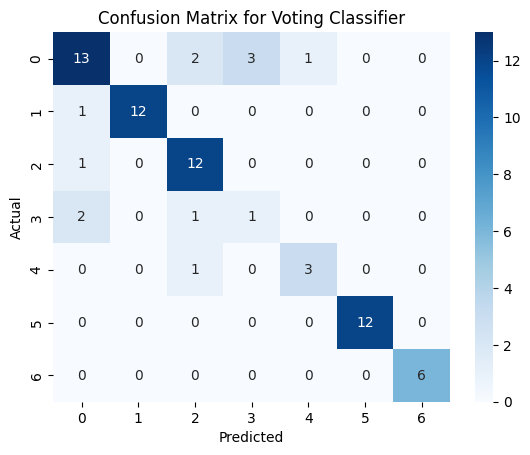

In [ ]:
# Evaluate the model
accuracy_voting = accuracy_score(y_test, y_pred_voting)
print(f"Voting Classifier Accuracy: {accuracy_voting}")
print(classification_report(y_test, y_pred_voting))

cm_voting = confusion_matrix(y_test, y_pred_voting)
sns.heatmap(cm_voting, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Voting Classifier')
plt.show()

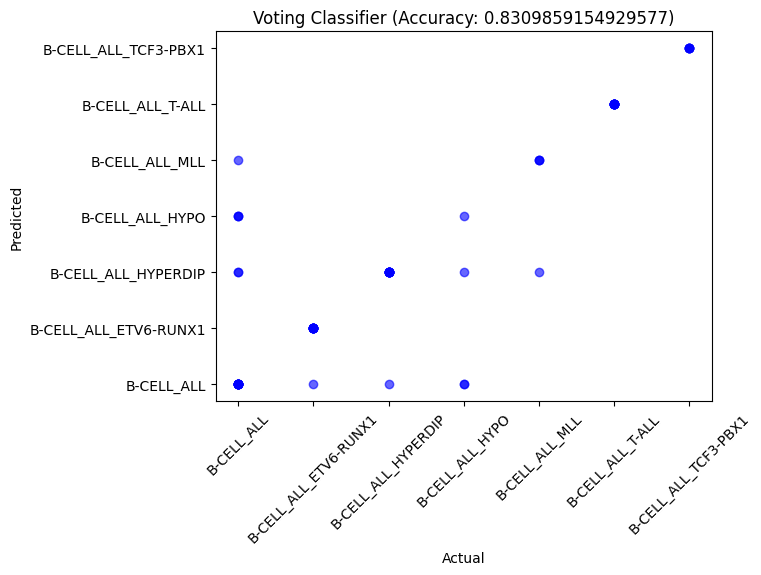

In [ ]:
#Plot for voting classifier
labels = sorted(list(set(y_test.values) | set(y_pred_voting)))

# Map the labels to numerical indices for scatter plotting
y_test_mapped = [labels.index(label) for label in y_test.values]
y_pred_mapped = [labels.index(label) for label in y_pred_voting]

# Create the scatter plot
plt.scatter(y_test_mapped, y_pred_mapped, color='blue', alpha=0.6)
plt.title(f"Voting Classifier (Accuracy: {accuracy_voting})")

# Set the ticks and labels on both axes
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45)
plt.yticks(ticks=range(len(labels)), labels=labels)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

## Accuracy Score

In [ ]:
# prompt: generate final accuracies and visualisations

print(f"Decision Tree Accuracy: {100*accuracy_dt:.2f}")
print(f"Random Forest Accuracy: {100*accuracy_rf:.2f}")
print(f"Accuracy with PCA: {100*accuracy_pca:.2f}")
print(f"Accuracy with LDA: {100*accuracy_lda:.2f}")
print(f"Accuracy with t-SNE: {100*accuracy_tsne:.2f}")
print(f"Voting Classifier Accuracy: {100*accuracy_voting:.2f}")

Decision Tree Accuracy: 74.65
Random Forest Accuracy: 85.92
Accuracy with PCA: 77.46
Accuracy with LDA: 78.87
Accuracy with t-SNE: 76.06
Voting Classifier Accuracy: 83.10


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# Assuming 'X' and 'y' are your feature matrix and target variable
# and 'rf_classifier' is your RandomForestClassifier instance

kf = KFold(n_splits=6, shuffle=True, random_state=42)

accuracies = []
for train_index, test_index in kf.split(X):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Apply SMOTE to each fold
    sm = SMOTE(random_state=42)
    X_train_fold, y_train_fold = sm.fit_resample(X_train_fold, y_train_fold)

    rf_classifier.fit(X_train_fold, y_train_fold)
    y_pred_fold = rf_classifier.predict(X_test_fold)
    accuracy = accuracy_score(y_test_fold, y_pred_fold)
    accuracies.append(accuracy)

print("Cross-validation accuracies:", accuracies)
print("Average accuracy:", np.mean(accuracies))

Cross-validation accuracies: [0.8936170212765957, 0.851063829787234, 0.8297872340425532, 0.8085106382978723, 0.8297872340425532, 0.9130434782608695]
Average accuracy: 0.8543015726179463


## Interpretations

Top 50 Feature ranking:
1. feature 218856_at (0.007649419630987122)
2. feature 221113_s_at (0.006027204644434835)
3. feature 220451_s_at (0.005561663682090003)
4. feature 210116_at (0.00526672927711395)
5. feature 219563_at (0.004756574044814096)
6. feature 212158_at (0.004656152100501421)
7. feature 219463_at (0.004449417583550889)
8. feature 219686_at (0.004347890460671201)
9. feature 209881_s_at (0.004342944686537256)
10. feature 219191_s_at (0.004315615400721821)
11. feature 204446_s_at (0.004279844974143137)
12. feature 212151_at (0.003773637011816901)
13. feature 206032_at (0.0036824078484947067)
14. feature 213017_at (0.0036637870506132366)
15. feature 205769_at (0.003390947830040581)
16. feature 210982_s_at (0.003341993261825567)
17. feature 220418_at (0.003250644688137952)
18. feature 201695_s_at (0.0032264304525331427)
19. feature 204890_s_at (0.003209524982968341)
20. feature 218966_at (0.0032055130126187907)
21. feature 204030_s_at (0.0031900566188348754)
22. feature 211210

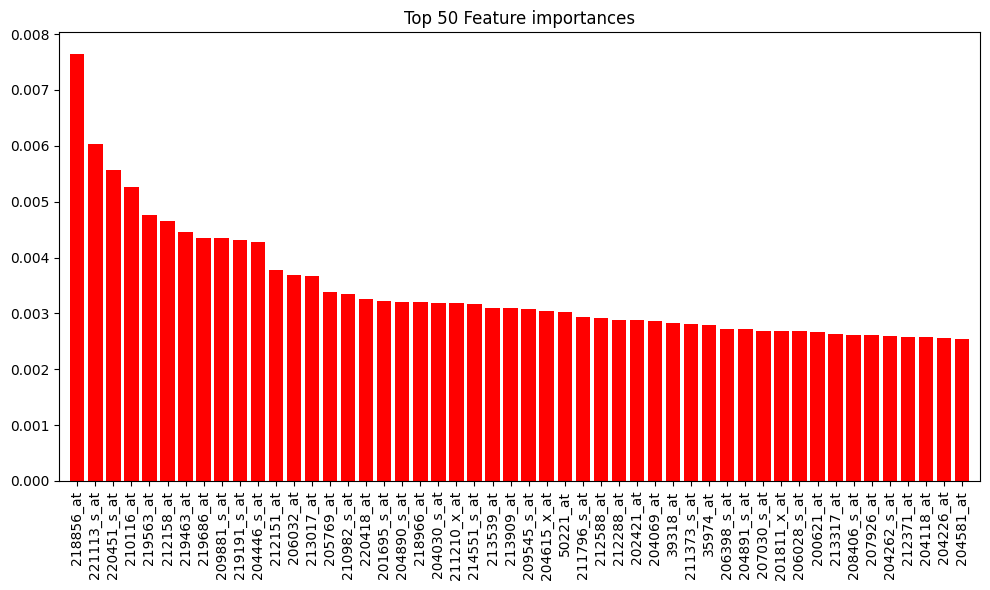

In [ ]:
# Feature Importance from Random Forest (Top 100)
importances = rf_classifier.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort feature importances in descending order
n_imp_features = 50  # Number of top features to select
# Select the top 100 features
top_n_indices = indices[:n_imp_features]
top_n_importances = importances[top_n_indices]
top_n_features = X.columns[top_n_indices]

# Print the top n feature ranking
print(f"Top {n_imp_features} Feature ranking:")
for f in range(len(top_n_features)):
    print(f"{f+1}. feature {top_n_features[f]} ({top_n_importances[f]})")

# Visualize the top n feature importances
plt.figure(figsize=(10, 6))
plt.title(f"Top {n_imp_features} Feature importances")
plt.bar(range(len(top_n_features)), top_n_importances, color="r", align="center")
plt.xticks(range(len(top_n_features)), top_n_features, rotation=90)
plt.xlim([-1, len(top_n_features)])
plt.tight_layout()
plt.show()